In [68]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

for style in plt.style.available:
    print(style)

plt.style.use('classic')

Solarize_Light2
_classic_test_patch
_mpl-gallery
_mpl-gallery-nogrid
bmh
classic
dark_background
fast
fivethirtyeight
ggplot
grayscale
seaborn-v0_8
seaborn-v0_8-bright
seaborn-v0_8-colorblind
seaborn-v0_8-dark
seaborn-v0_8-dark-palette
seaborn-v0_8-darkgrid
seaborn-v0_8-deep
seaborn-v0_8-muted
seaborn-v0_8-notebook
seaborn-v0_8-paper
seaborn-v0_8-pastel
seaborn-v0_8-poster
seaborn-v0_8-talk
seaborn-v0_8-ticks
seaborn-v0_8-white
seaborn-v0_8-whitegrid
tableau-colorblind10


In [2]:
tflops = 622*10**9  

rtt = 13*10**-9 # seconds

lflop = tflops * rtt  # flops
print(f"lflop: {lflop} Mflops")
print(f"sec : {1/(tflops/1000)} Mflops/byte")
print(f"sec : {1/(tflops/(2*10**5))} flops/byte")

lflop: 8086.0 Mflops
sec : 1.6077170418006431e-09 Mflops/byte
sec : 3.2154340836012864e-07 flops/byte


In [70]:


from typing import Iterable, Sized


@dataclass
class SimulationParameters:
    executors: int
    latency : int 
    database_size: int
    passwords_size: int
    mean_password_chars: int 
    network_ops: int
    disk_ops: int
    hash_size : int 
    pass

@dataclass
class SimulationResult:
    runtime : float 
    comm_time : float 
    comp_time : float 
    speedup : float
    cc_ratio: float
    efficiency : float
    database_size : int 
    password_size : int 
    cost: float
    executors: int
    pass

class Simulation:
    def __init__(self, params: SimulationParameters):
        self.p = params
        pass

    def execute(self, executors, database_size)-> np.ndarray:
        results = np.empty((len(database_size),len(executors)),dtype=object)
        oldparams = self.p
        for i,ds in enumerate(database_size):
            for j,ex in enumerate(executors):
                self.p.executors = ex
                self.p.database_size = ds
                result = SimulationResult(
                    runtime=self.runtime(),
                    comm_time=self.t_comm(),
                    comp_time=self.t_comp(),
                    speedup=self.speedup(),
                    cc_ratio=self.t_comm()/self.t_comp(),
                    database_size=self.p.database_size,
                    password_size=self.p.passwords_size,
                    executors=self.p.executors,
                    efficiency=self.efficiency(),
                    cost= self.runtime() *  self.p.executors
                )
                results[i,j] = result
                pass
        self.p = oldparams
        return results
    
    def t_comm(self) -> float:
        return NotImplemented
    def t_comp(self) -> float:
        return NotImplemented
    def t_seq(self)->float:
        return NotImplemented
    def space(self)-> float:
        return NotImplemented
    

    def runtime(self)-> float :
        return self.t_comp() + self.t_comm()
    def speedup(self) -> float:
        return self.t_seq()/self.runtime()
    def efficiency(self) -> float:
        return (self.speedup() / self.p.executors)*100
    def L(self,x):
        return x*self.p.disk_ops
    def Latency(self):
        return self.p.executors*self.p.latency
    def S(self,x):
        return x*self.p.network_ops
    def H(self,x):
        return (x*512)
    def C(self,x,y):
        return (((x*y)*self.p.hash_size)*3)

    pass


sha256_sim_param = SimulationParameters(
    executors=1,
    latency=50000, #flops 
    database_size=1,
    passwords_size=10**6,
    mean_password_chars=16,
    network_ops=1000,  # flops/byte
    disk_ops=2*10**4,       # flops/byte
    hash_size=32  ,                 # bytes
)


simulations :dict[str,np.ndarray] = {}

In [71]:
class SequentialSimulation(Simulation):
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size, self.p.passwords_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass

sim = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[10**i for i in range(1,10)])
print(f"Runtime {sim[8,0].comp_time}, Tcomm {sim[8,0].comm_time}")


Runtime 96000000512000000, Tcomm 640320000000000


In [72]:
simparams = [i for i in range(1,40)], np.arange(10**6,10**7,10**4)

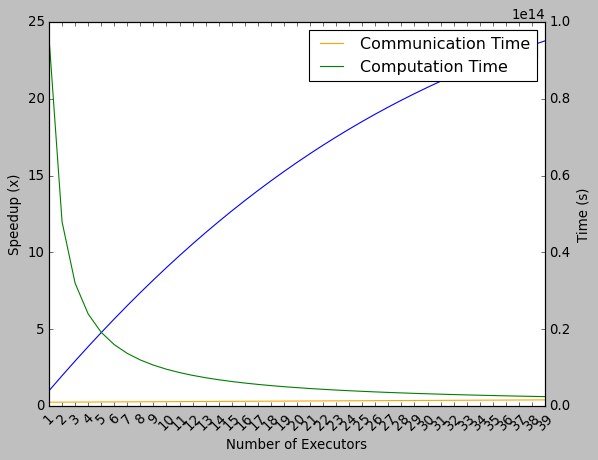

In [73]:
from matplotlib.pyplot import xlabel, ylabel

class LinearSimulation(SequentialSimulation):
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars)*self.p.executors  + self.S(self.p.database_size*self.p.hash_size) + self.Latency()
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size)
    pass



scale = LinearSimulation(sha256_sim_param).execute(*simparams)
simulations["MasterWorker"] = scale
def plot_speedup(scale,index):
# set labels in plot
    xlabel('Number of Executors')
    ylabel('Speedup (x)')
    plt.plot([x for x in range(len(scale[index]))], [x.speedup for x in scale[index]] , label='Speed Up')
    # add to x the correct labels
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.legend()
    # add third axis 
    plt.twinx()
    plt.ylabel('Time (s)')
    plt.plot([x for x in range(len(scale[index]))], [s.comm_time for s in scale[index]], label='Communication Time', color='orange')
    plt.plot([x for x in range(len(scale[index]))], [s.comp_time for s in scale[index]], label='Computation Time', color='green')
    plt.legend()
    plt.show()

plot_speedup(scale,0)  # Plot for the first instance of scale

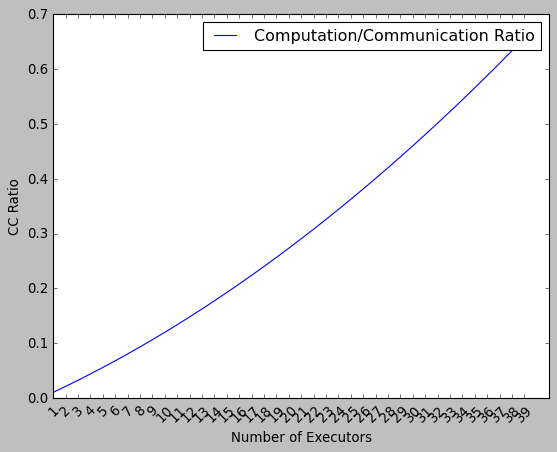

In [74]:
def plot_cc_ratio(scale,index):
    plt.plot([x for x in range(len(scale[index]))], [s.cc_ratio for s in scale[index]], label='Computation/Communication Ratio')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.xlabel('Number of Executors')
    plt.ylabel('CC Ratio')
    plt.legend()
    plt.show()

plot_cc_ratio(scale,0)  # Plot for the first instance of scale

[np.float64(0.9995051975441571), np.float64(1.9777965725027582), np.float64(2.9345947048220924), np.float64(3.869673130324978), np.float64(4.78285625403926), np.float64(5.674017158298795), np.float64(6.543075327659754), np.float64(7.389994311502651), np.float64(8.214779343904643), np.float64(9.017474938996816), np.float64(9.798162478594348), np.float64(10.556957807428997), np.float64(11.294008849845167), np.float64(12.009493260363069), np.float64(12.703616119082147), np.float64(13.376607681509508), np.float64(14.028721191064038), np.float64(14.660230761236273), np.float64(15.27142933318533), np.float64(15.862626713431938), np.float64(16.43414769526527), np.float64(16.98633026652241), np.float64(17.519523905523894), np.float64(18.034087966156207), np.float64(18.530390152380406), np.float64(19.00880508181361), np.float64(19.4697129374726), np.float64(19.91349820628363), np.float64(20.340548502544923), np.float64(20.751253474174018), np.float64(21.146003789277092), np.float64(21.525190200

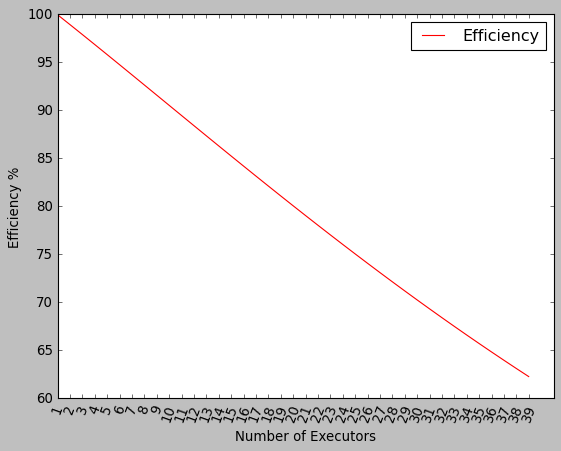

In [75]:
def plot_efficiency(scale,index):
    efficiency = [s.efficiency for s in scale[index]]
    plt.plot([x for x in range(len(efficiency))], efficiency, label='Efficiency', color='red')
    plt.xlabel('Number of Executors')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=70)
    plt.ylabel('Efficiency %')
    plt.legend()
    plt.show()

print([s.speedup for s in scale[0]])
plot_efficiency(scale,10)  # Plot for the first instance of scale

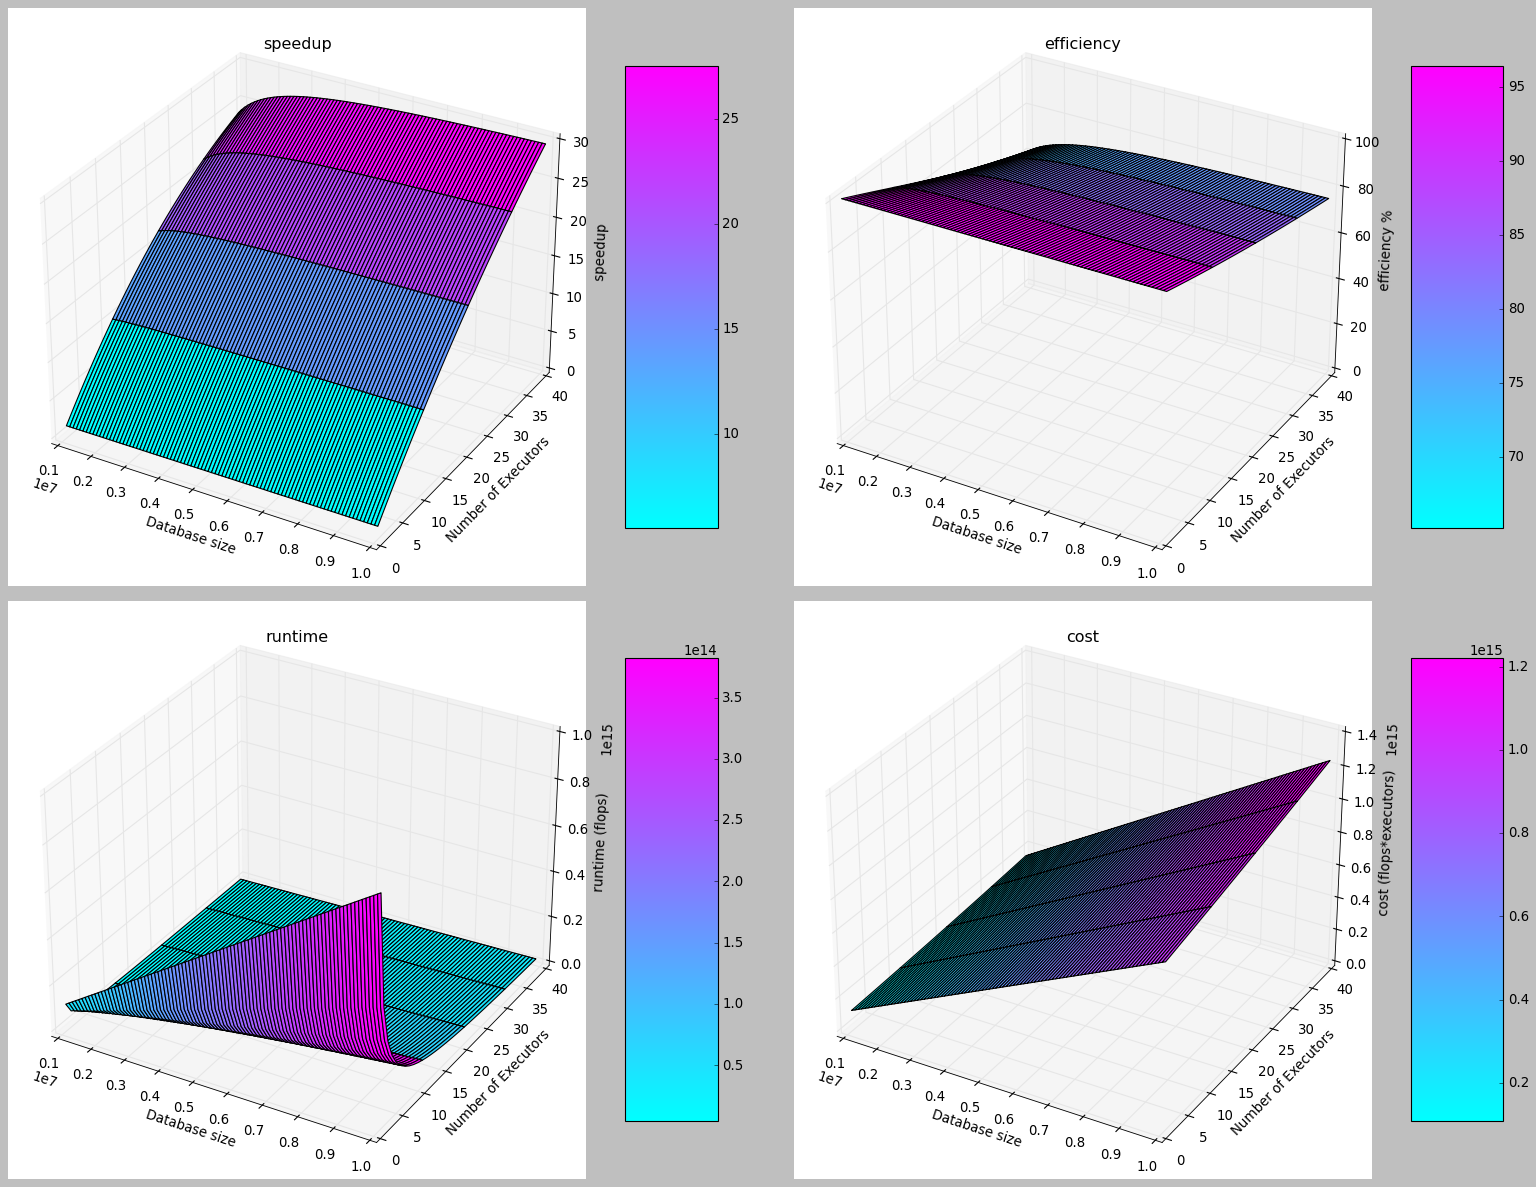

In [76]:
import math
from numpy import meshgrid


def plot_measure(result: np.ndarray, measure: str):

    X_vals = [x[0].database_size for x in result]
    Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
    Z = np.zeros((len(X_vals), len(Y_vals)))
    for i in range(len(X_vals)):
        for j in range(len(Y_vals)):
            Z[i, j] = result[i][j].__getattribute__(measure)
    print("X shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)
    print("Z min/max:", np.nanmin(Z), np.nanmax(Z))
    fig = plt.figure()
    ax = fig.add_axes((0, 0, 2, 2), projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Database size')
    ax.set_ylabel('Number of Executors')
    ax.set_zlabel(measure)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()


def plot_all_measures(result: np.ndarray):
    X_vals = [x[0].database_size for x in result]
    Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
    Zs = {}
    for measure in ['speedup', 'efficiency', 'runtime', 'cost']:
        Z = np.zeros((len(X_vals), len(Y_vals)))
        for i in range(len(X_vals)):
            for j in range(len(Y_vals)):
                Z[i, j] = result[i][j].__getattribute__(measure)
        Zs[measure] = Z
    fig = plt.figure(figsize=(20, 15))
    for idx, (measure, Z) in enumerate(Zs.items(), start=1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        ## print logscale surface 
        surf = ax.plot_surface(X, Y, Z, cmap='cool')
        ax.set_xlabel('Database size')
        ax.set_ylabel('Number of Executors')
        unit= ""
        if 'runtime' in measure:
            unit = "(flops)"
            pass
        elif 'cost' in measure:
            unit = "(flops*executors)"
            pass
        elif 'efficiency' in measure:
            ax.set_autoscalez_on(False)
            ax.set_zlim(0,100)
            unit = "%"
        ax.set_zlabel(measure + " " + unit)
        ax.set_title(f'{measure}')
        fig.colorbar(surf, ax=ax, shrink=0.8, aspect=5)
    plt.tight_layout()
    plt.show()
    
    
plot_all_measures(scale)

In [77]:
class RingSimulation(SequentialSimulation):

    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size)+ self.t_transitory()
    
    def t_comp(self) -> float:
        return self.t_task()

    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors) + self.S(self.p.database_size/self.p.executors) + self.Latency()
    pass

scale = RingSimulation(sha256_sim_param).execute(*simparams)
simulations["FixedTasksRing"] = scale

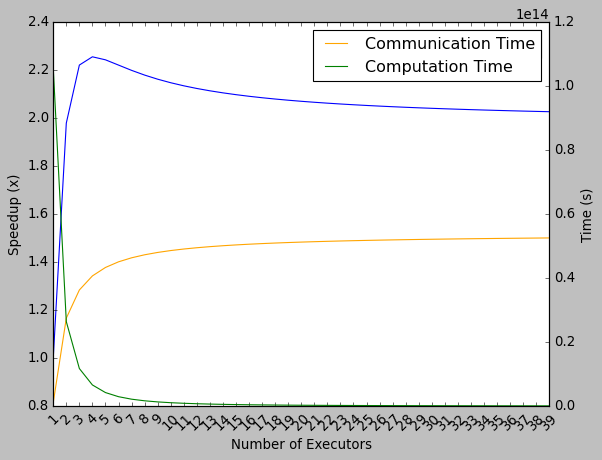

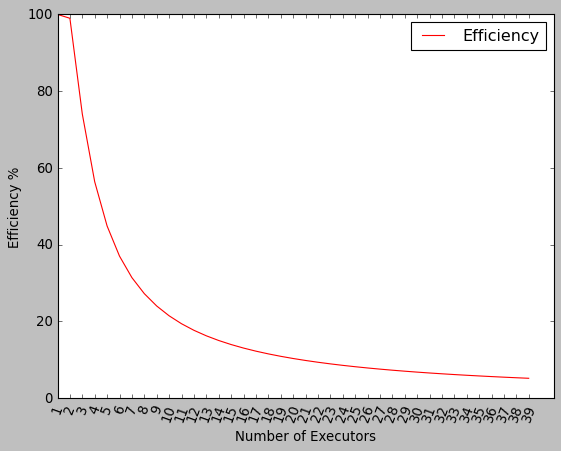

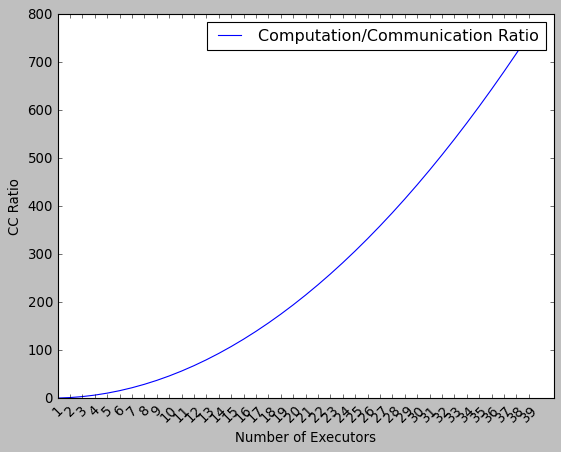

In [78]:
plot_speedup(scale,10)  # Plot for the first instance of scale
plot_efficiency(scale,10)  # Plot for the first instance of scale
plot_cc_ratio(scale,10)  # Plot for the first instance of scale

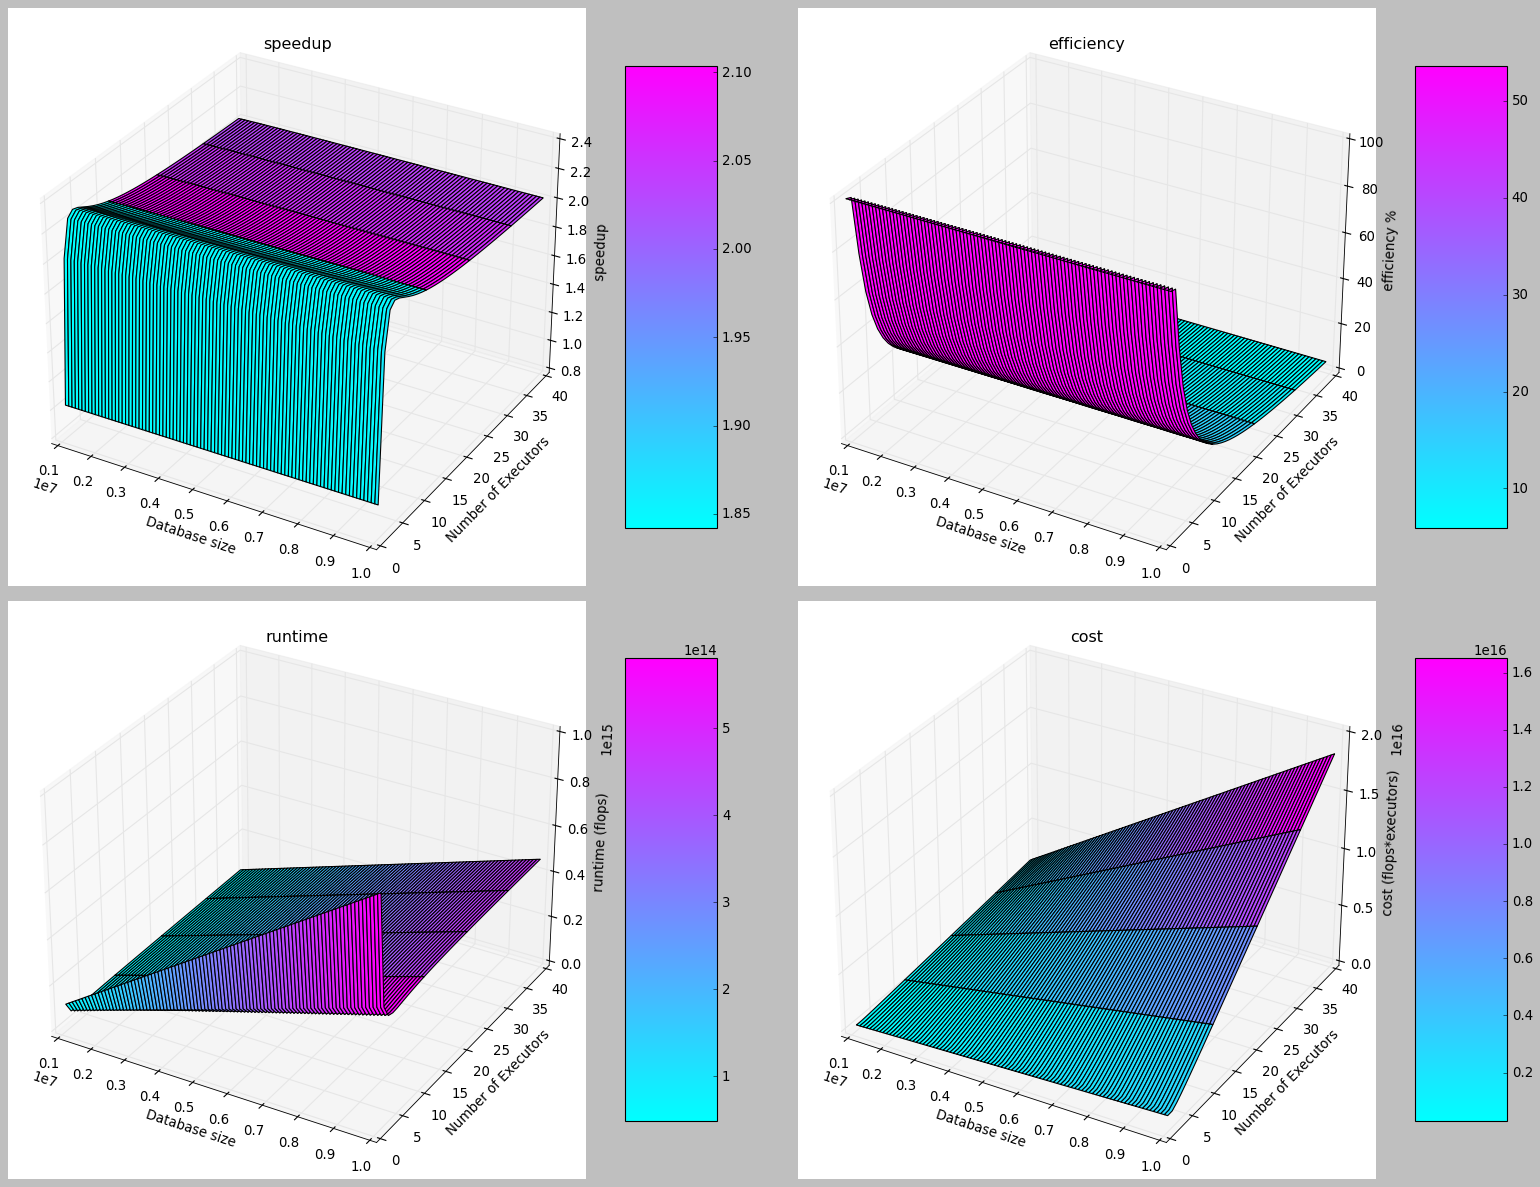

In [79]:
plot_all_measures(scale)

In [80]:
class BlockRingSimulation(SequentialSimulation):
    def __init__(self, params: SimulationParameters, task_size=2000):
        super().__init__(params)
        self.task_size = task_size
        pass
 
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ self.Latency()
    
    def t_comp(self) -> float:
        tcomp = (self.t_task()*self.n_tasks()) + self.t_transitory()
        return tcomp
    
    def n_tasks(self):
        tasks = math.ceil(self.p.database_size / self.task_size)
        return tasks
    
    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.task_size, self.p.passwords_size/self.p.executors) + self.S(self.task_size*self.p.hash_size) +self.Latency()
    pass

scale = BlockRingSimulation(sha256_sim_param).execute(*simparams)
simulations["DynamicTasksRing"] = scale

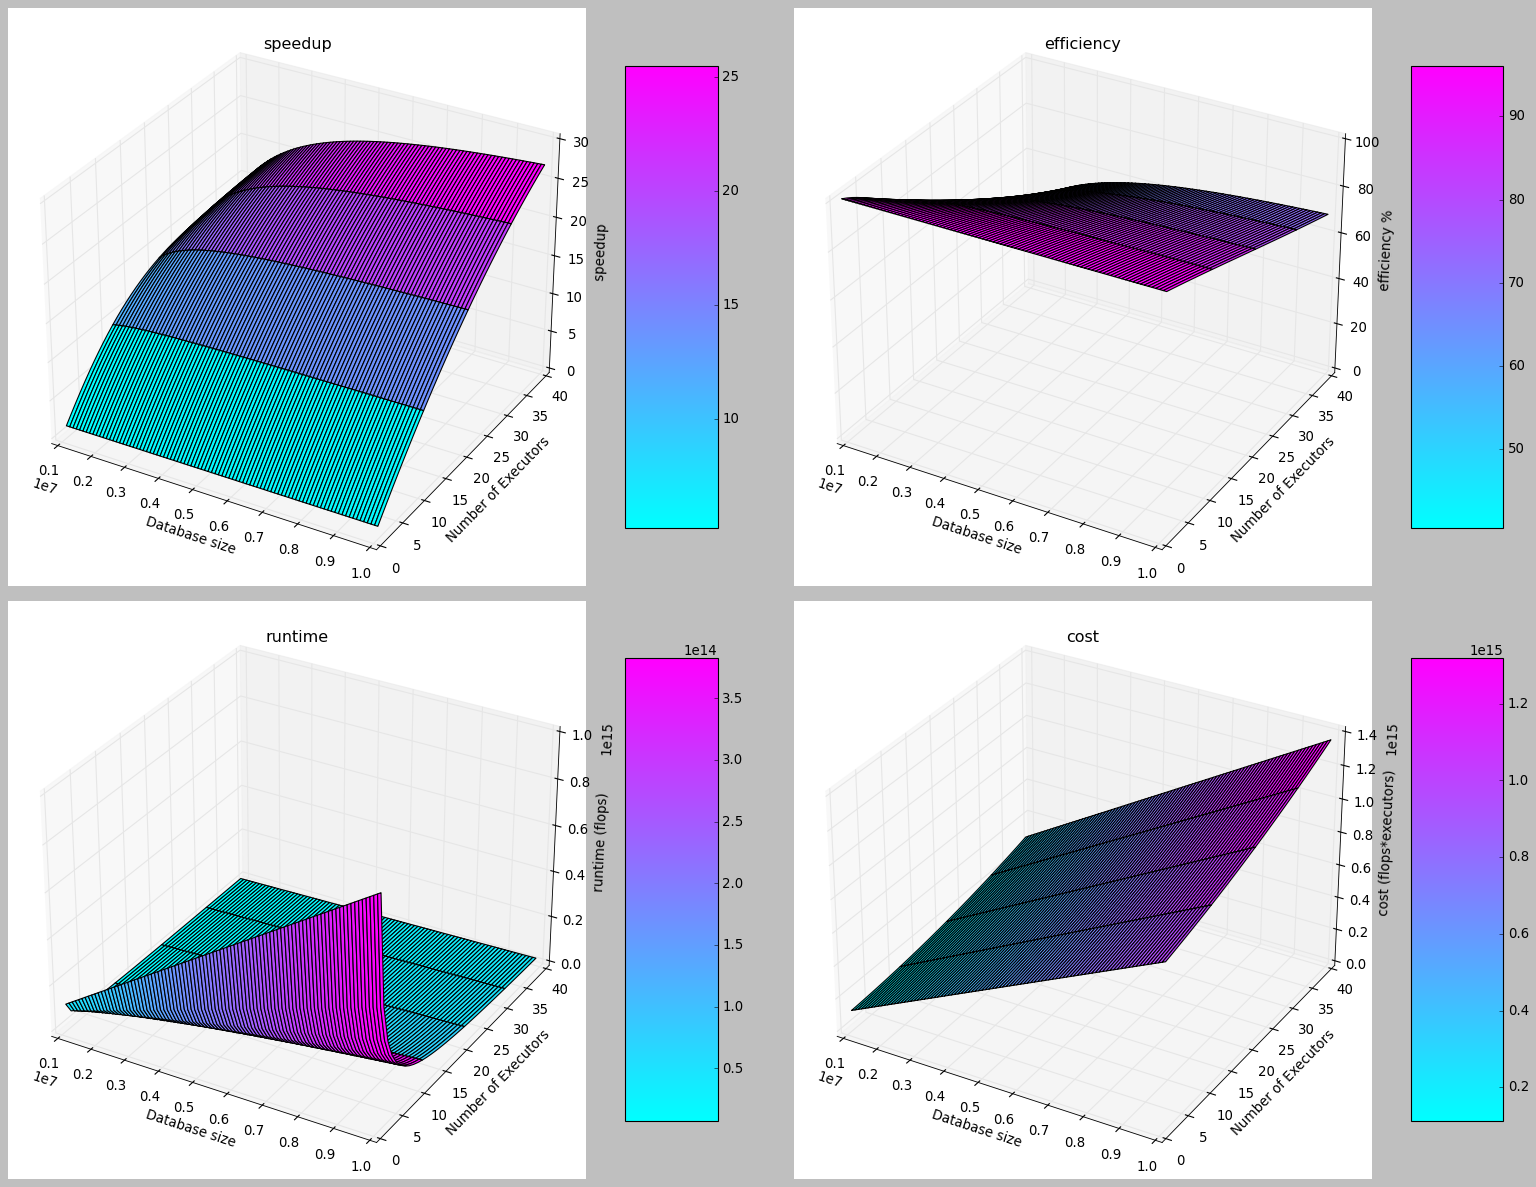

In [81]:
plot_all_measures(scale)

$T_{seq}= L(N)+H(N)+L(K)+H(K)+C_h(K,N)$

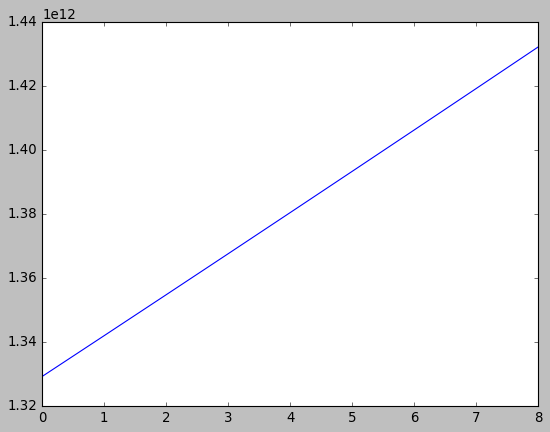

In [82]:




class DHTSequentialSimulation(Simulation):
    def __init__(self, params: SimulationParameters, hashmap_size=10**6):
        super().__init__(params)
        self.hashmap_size = hashmap_size
        pass
    @staticmethod
    def p_collision(keys,size):
        prob = 1 - math.exp(- (keys*(keys-1)) / (2*size))
        return prob
    
    @staticmethod
    def expected_collision(keys,size):
        coll = keys-size+size*((size-1)/size)**keys
        return coll if coll > 1 else 1
    
    def Ch(self, k: int, alloc_size: int)-> float:
        return ((k*self.expected_collision(self.p.database_size,alloc_size))) + k*100 + self.p.database_size*100
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 
    
    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size,self.hashmap_size) + self.H(self.p.database_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass

res = DHTSequentialSimulation(sha256_sim_param,10**6).execute(*simparams)
seq = SequentialSimulation(sha256_sim_param).execute(*simparams)
plt.plot([x for x in range(9)], [res[x,10].runtime for x in range(9)], label='time')
plt.show()

$T_{comp}=H(N)+H(K)+C_h(K,N)$
$T_{comm}= L(N)+L(K)+S(N)+S(K)$

Runtime 464548352252.736, Tcomm 43680050000, Seq 104691712000000
Excpected collisions  1 Probaility  4.999870002331264e-05


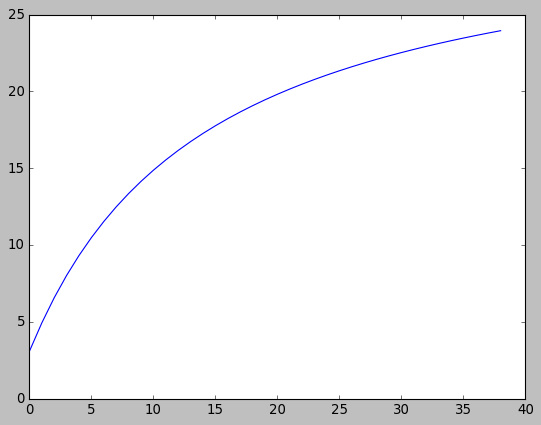

In [83]:
from numpy import ndarray



class DHTSimulation(DHTSequentialSimulation,SequentialSimulation):
    def __init__(self, params: SimulationParameters, hashmap_size=10 ** 6):
        super().__init__(params, hashmap_size)
        pass
    
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size, self.hashmap_size)

    def t_comm(self) -> float:
        return self.L(self.p.passwords_size)+ self.L(self.p.database_size) + self.S(self.p.passwords_size) + self.S(self.p.database_size)+ self.Latency()
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size,self.hashmap_size*self.p.executors) + self.H(self.p.database_size)  
    pass
seq = SequentialSimulation(sha256_sim_param).execute(*simparams)
sim = DHTSimulation(sha256_sim_param,10**6).execute(*simparams)
print(f"Runtime {sim[8,0].runtime}, Tcomm {sim[8,0].comm_time}, Seq {seq[8,0].runtime}")
print("Excpected collisions ", DHTSimulation.expected_collision(10**6,10**16) , "Probaility ", DHTSimulation.p_collision(10**6,10**16))
simulations["DistributedHashMap"] = sim
#plot speedup
plt.plot([x for x in range(len(sim[8]))], [ x.speedup for x in sim[8]] , label='Speed Up')

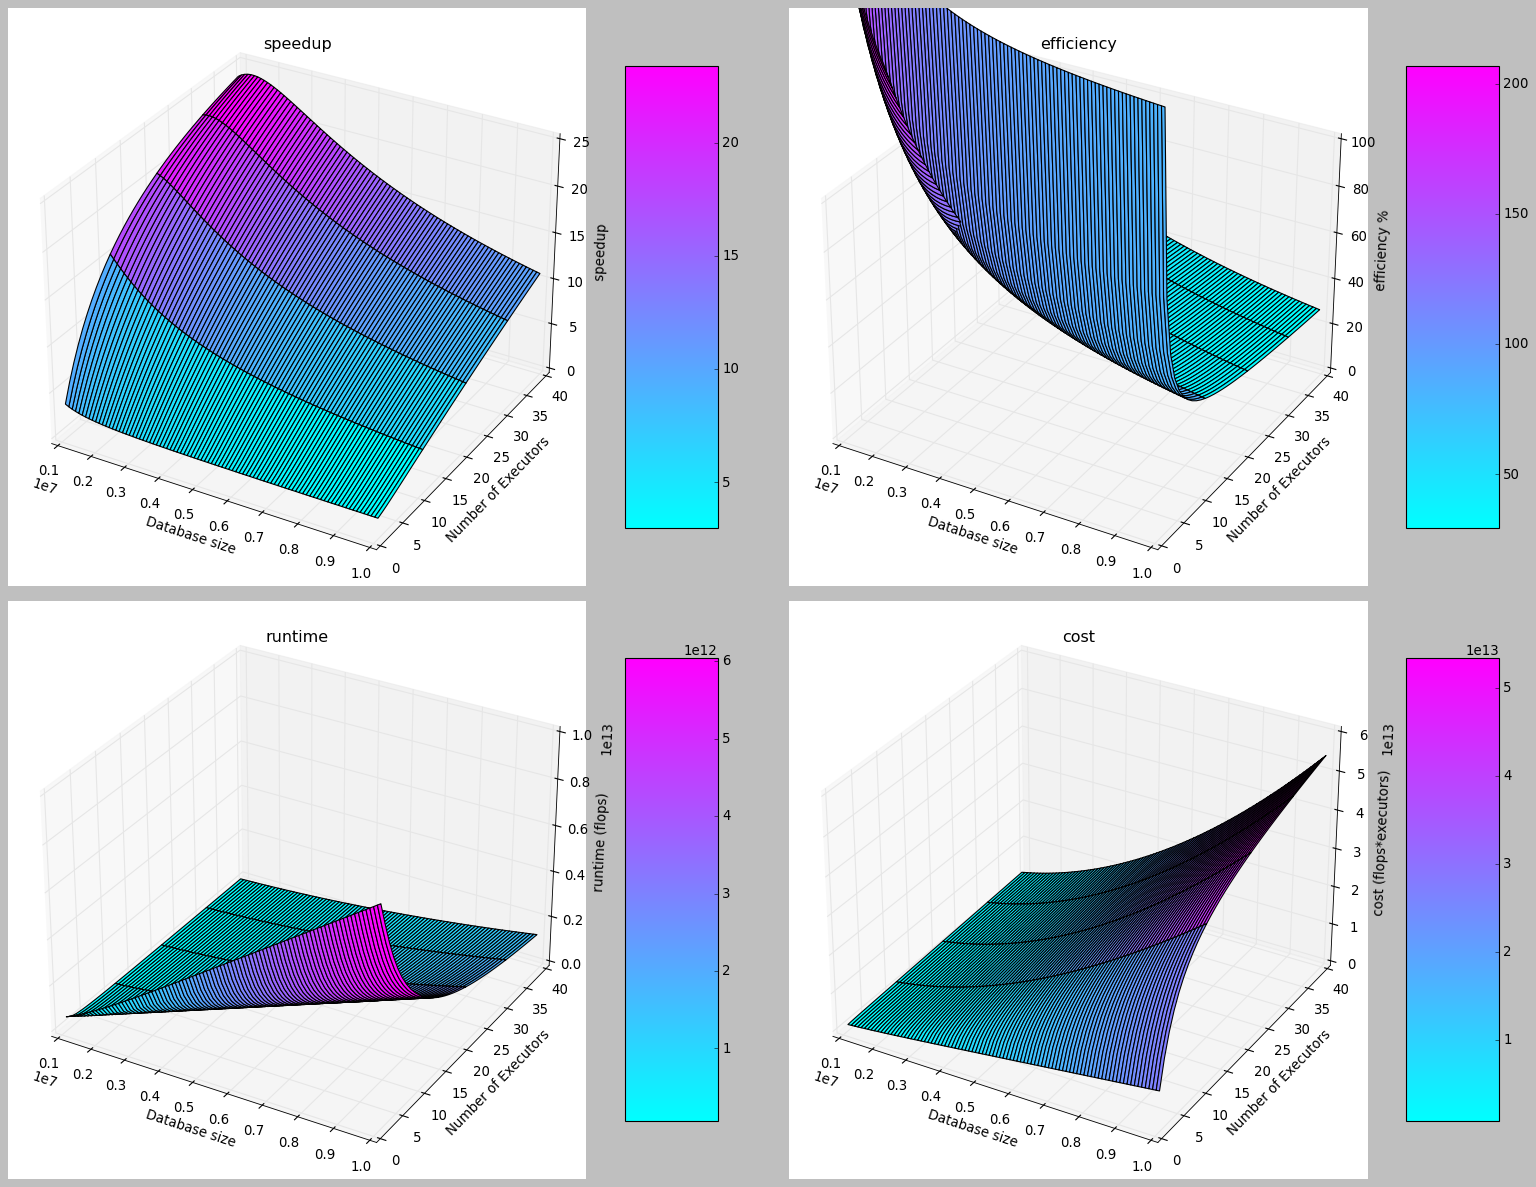

In [84]:
plot_all_measures(sim)

Runtime 464548352252.736, Tcomm 43680050000, Seq 104691712000000
Excpected collisions  1 Probaility  4.999870002331264e-05


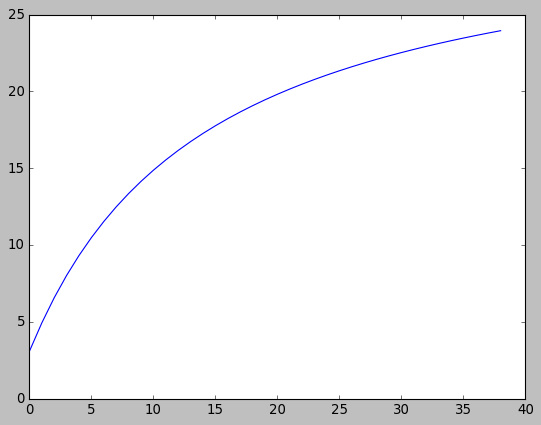

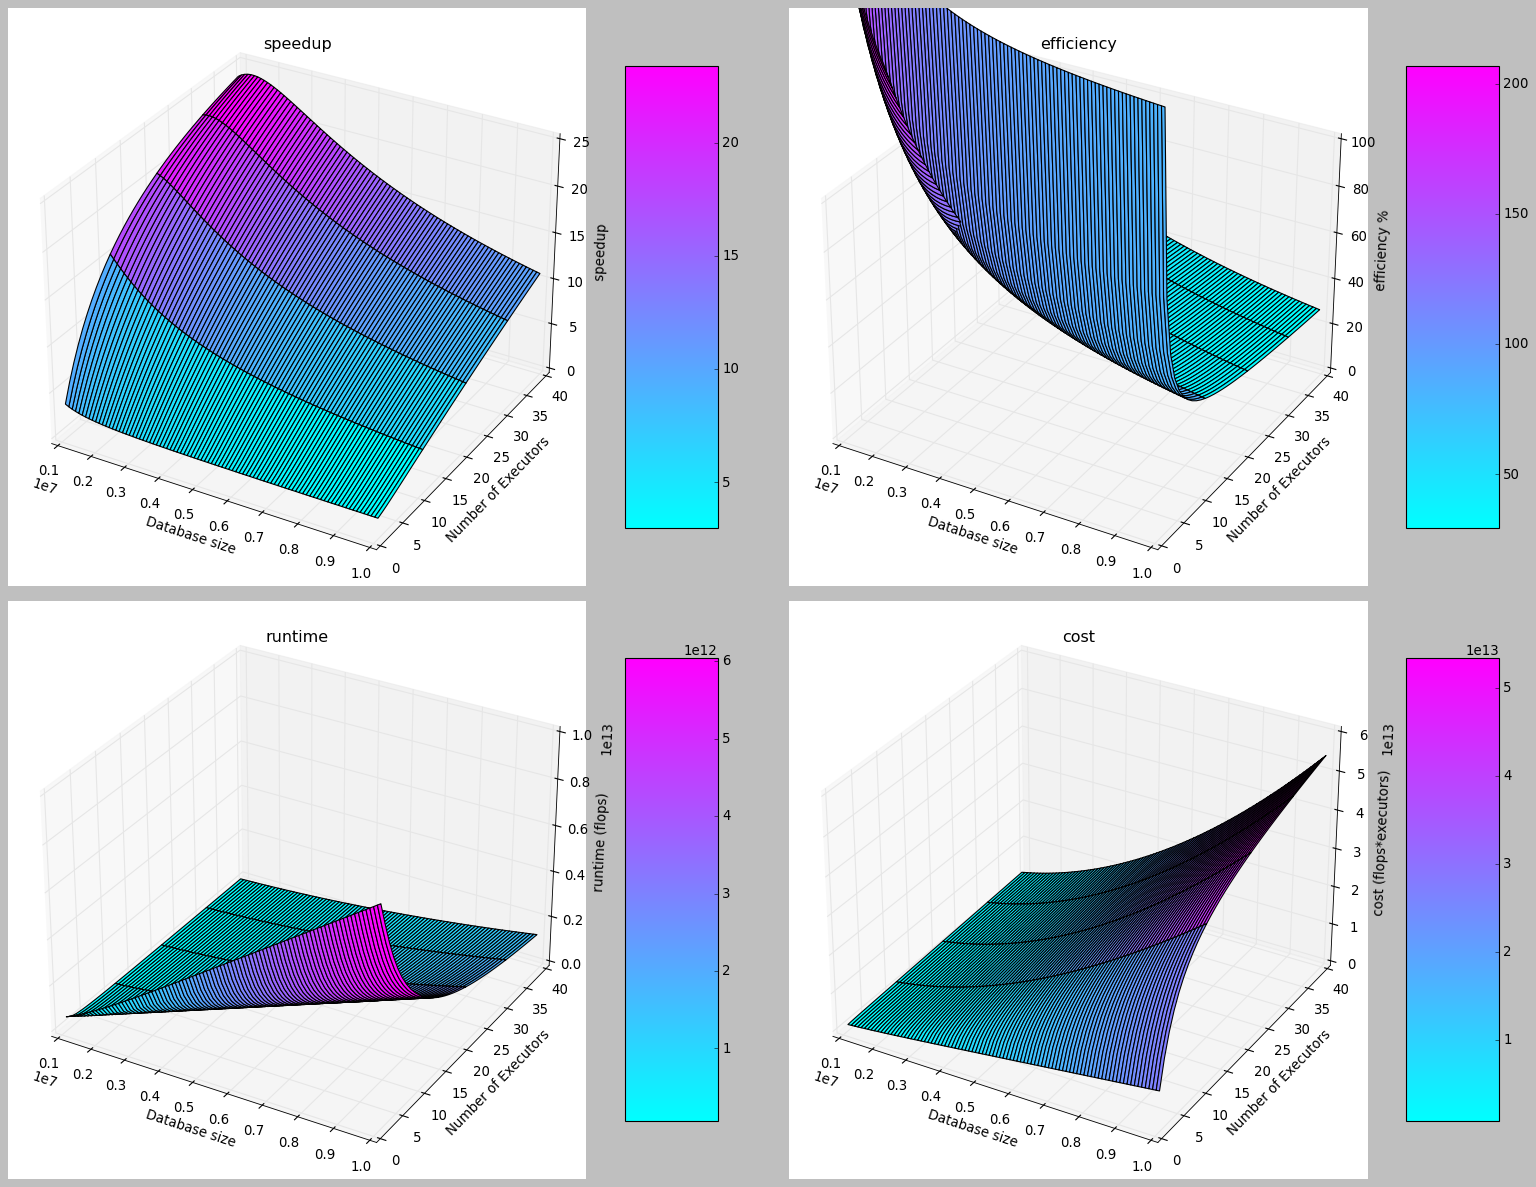

In [85]:
class DHTVsLinear(DHTSequentialSimulation,SequentialSimulation):
    def __init__(self, params: SimulationParameters, hashmap_size=10 ** 6):
        super().__init__(params, hashmap_size)
        pass
    
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size)+ self.L(self.p.database_size) + self.S(self.p.passwords_size*self.p.hash_size) + self.S(self.p.database_size)+ self.Latency()
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size,self.hashmap_size*self.p.executors) + self.H(self.p.database_size)  
    pass
seq = SequentialSimulation(sha256_sim_param).execute(*simparams)
sim = DHTSimulation(sha256_sim_param,10**6).execute(*simparams)
print(f"Runtime {sim[8,0].runtime}, Tcomm {sim[8,0].comm_time}, Seq {seq[8,0].runtime}")
print("Excpected collisions ", DHTSimulation.expected_collision(10**6,10**16) , "Probaility ", DHTSimulation.p_collision(10**6,10**16))
simulations["DistributedHashMap"] = sim
#plot speedup
plt.plot([x for x in range(len(sim[8]))], [ x.speedup for x in sim[8]] , label='Speed Up')
plot_all_measures(sim)

X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 0.9995051975441571 29.947198161557402
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 0.999500169572153 2.263591790013809
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 0.9991806159369906 27.31602347310106
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 1.7019942234191983 24.296178140542768


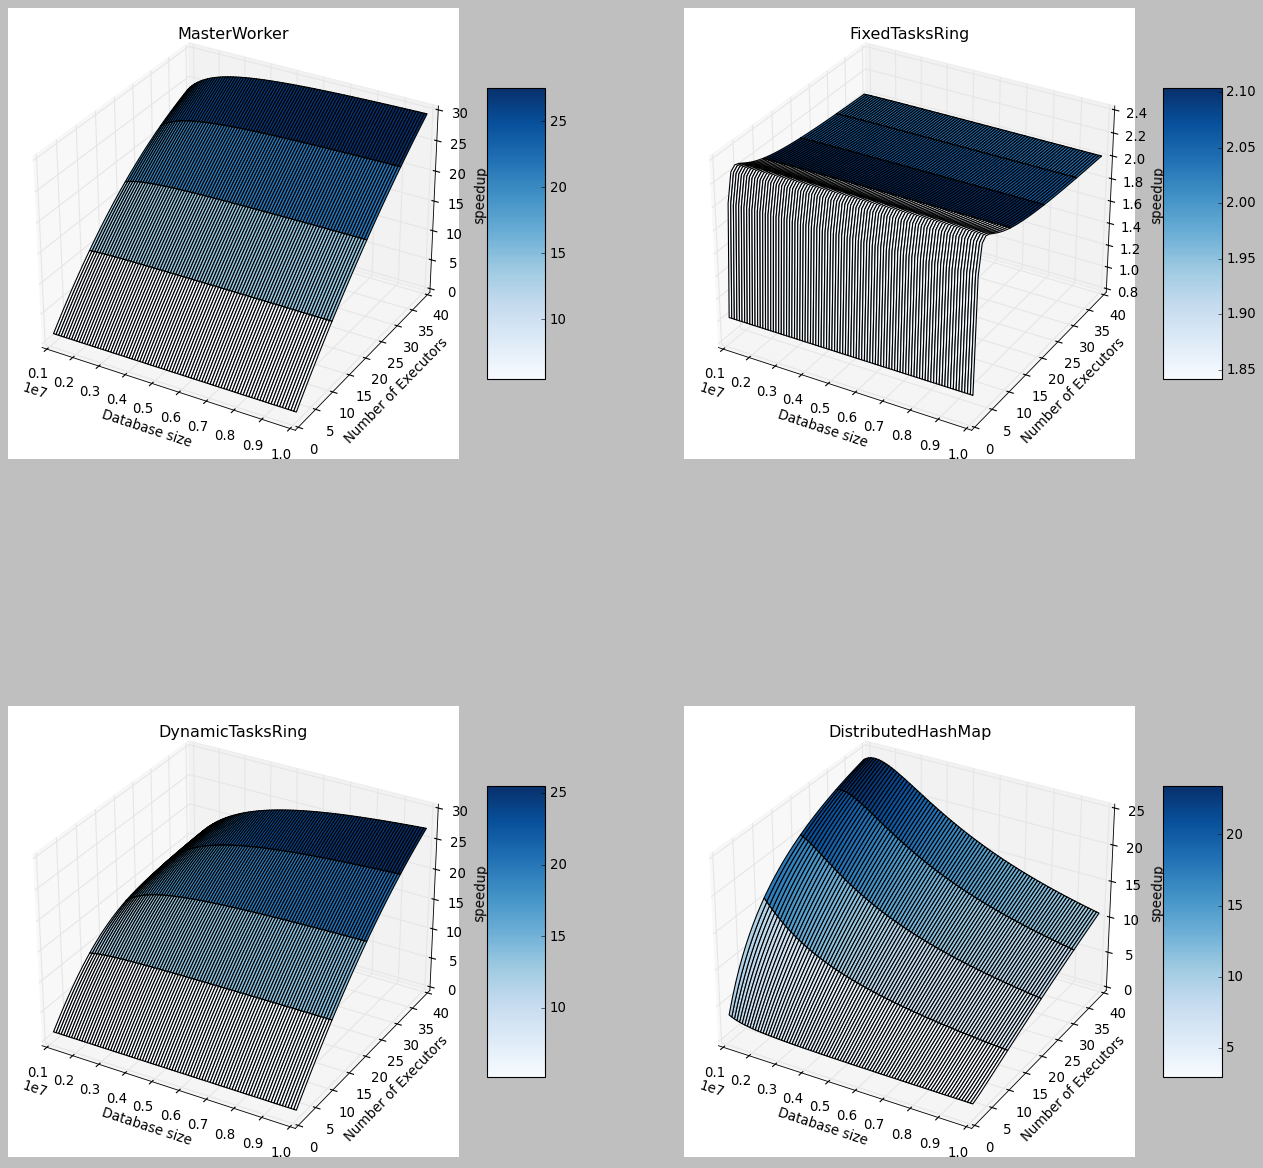

X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 60.964566500533465 99.96525374217156
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 5.194576672372712 99.96427302444995
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 34.68325777423183 99.93221320809478
X shape: (900, 39) Y shape: (900, 39) Z shape: (900, 39)
Z min/max: 28.471156725626013 323.176981037185


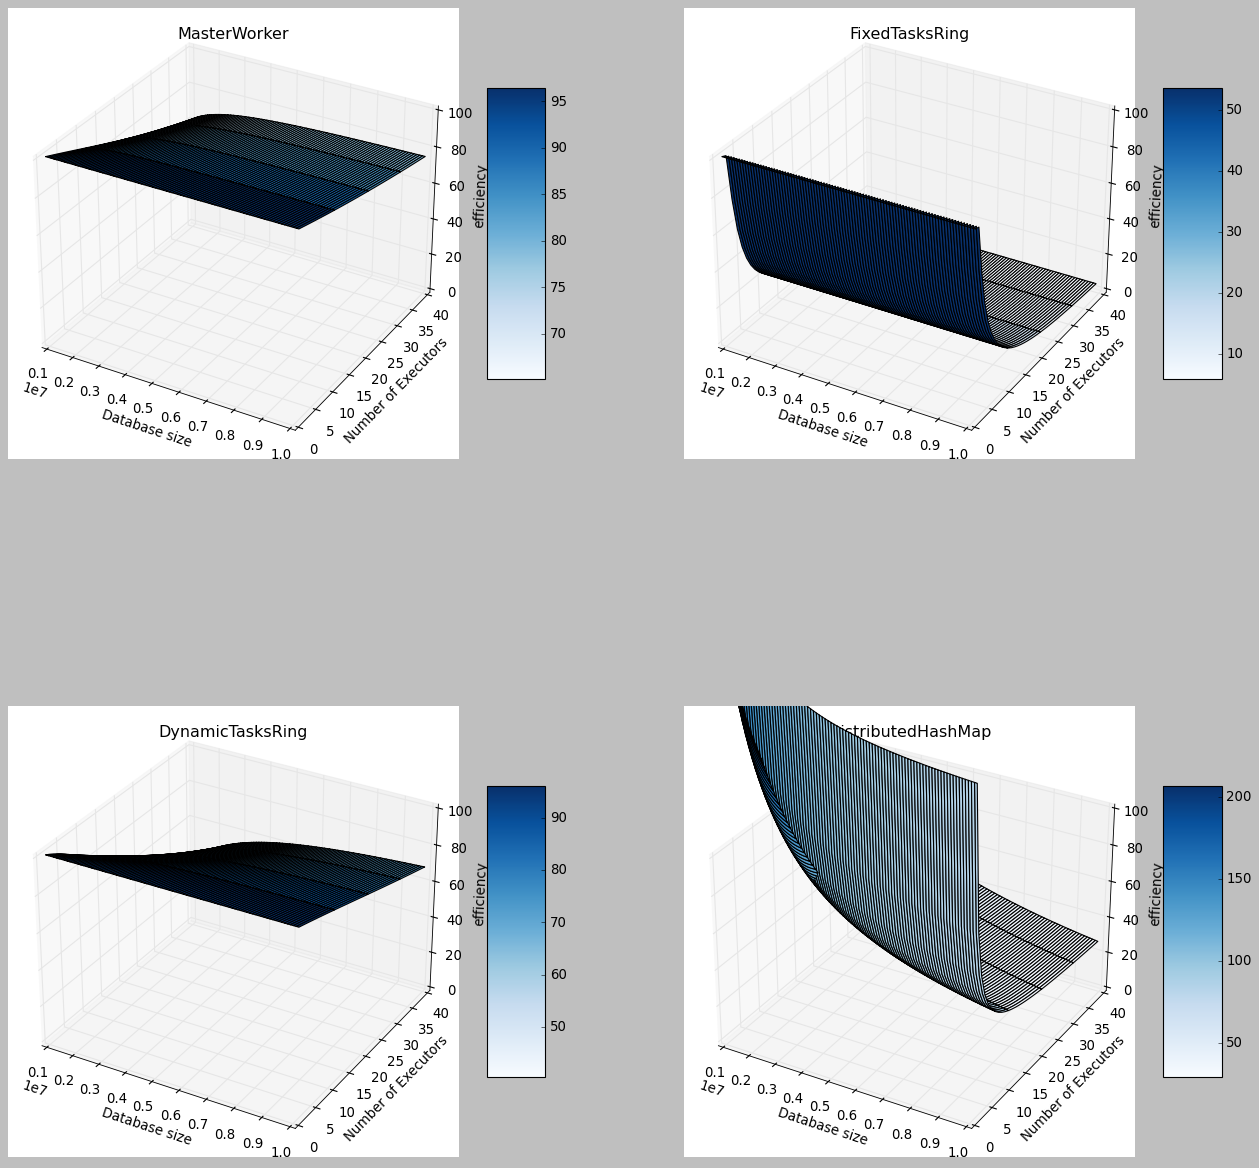

In [86]:
def compare_measure(results: list[np.ndarray], measure: str):
    fig = plt.figure(figsize=(20, 20))
    for idx,result in enumerate(results):
        X_vals = [x[0].database_size for x in result]
        Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
        X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
        Z = np.zeros((len(X_vals), len(Y_vals)))
        for i in range(len(X_vals)):
            for j in range(len(Y_vals)):
                Z[i, j] = result[i][j].__getattribute__(measure)
        print("X shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)
        print("Z min/max:", np.nanmin(Z), np.nanmax(Z))
        # create a subplot based on idx
        ax = fig.add_subplot(2, 2, idx+1, projection='3d')
        ax.set_title(f'{list(simulations.keys())[idx]}')
        surf = ax.plot_surface(X, Y, Z, cmap='Blues')
        ax.set_xlabel('Database size')
        ax.set_ylabel('Number of Executors')
        ax.set_zlabel(measure)
        if 'efficiency' in measure:
            ax.set_autoscalez_on(False)
            ax.set_zlim(0,100)
            unit = "%"
            pass
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
        pass
    plt.show()

compare_measure([simulations["MasterWorker"], simulations["FixedTasksRing"], simulations["DynamicTasksRing"], simulations["DistributedHashMap"]], 'speedup')
compare_measure([simulations["MasterWorker"], simulations["FixedTasksRing"], simulations["DynamicTasksRing"], simulations["DistributedHashMap"]], 'efficiency')
